# Block Normalizing Flow

Train a normalizing flow to predict where blocked throws land, conditioned on thrower position.

Training data: throwaways (type 22) that are immediately followed by a block (type 11).
Uses thrower position → turnover landing position. All coordinates direction-normalized.

In [1]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from nflows import flows, distributions, transforms

import joblib, os

np.random.seed(42)
torch.manual_seed(42)

DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': os.getenv('DB_USER', 'postgres'),
    'password': '',
    'host': 'localhost',
    'port': 5432
}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)

## 1. Load Block Data

Throwaways (type 22) that are immediately followed by a block (type 11).
Direction-normalized so all throws attack toward y=110.

In [2]:
conn = get_db_connection()
cur = conn.cursor()

cur.execute("""
    SELECT
        CASE WHEN e.team = g.away_team_id THEN -e.thrower_x ELSE e.thrower_x END as thrower_x,
        CASE WHEN e.team = g.away_team_id THEN 120 - e.thrower_y ELSE e.thrower_y END as thrower_y,
        CASE WHEN e.team = g.away_team_id THEN -e.turnover_x ELSE e.turnover_x END as dest_x,
        CASE WHEN e.team = g.away_team_id THEN 120 - e.turnover_y ELSE e.turnover_y END as dest_y
    FROM events e
    JOIN events nxt
        ON nxt.game_id = e.game_id
        AND nxt.event_number = e.event_number + 1
    JOIN games g ON e.game_id = g.game_id
    WHERE e.event_type = 22
      AND nxt.event_type = 11
      AND e.thrower_x IS NOT NULL AND e.thrower_y IS NOT NULL
      AND e.turnover_x IS NOT NULL AND e.turnover_y IS NOT NULL
""")
rows = cur.fetchall()

cur.close()
conn.close()

df = pd.DataFrame(rows)
print(f"Total block events: {len(df):,}")

Total block events: 12,795


In [3]:
# Drop NaNs and normalize coordinates to [0, 1]
df = df.dropna(subset=['dest_x', 'dest_y', 'thrower_x', 'thrower_y'])
print(f"After dropping NaNs: {len(df):,}")

df['thrower_x_norm'] = (df['thrower_x'] + 25) / 50
df['thrower_y_norm'] = df['thrower_y'] / 120
df['dest_x_norm'] = (df['dest_x'] + 25) / 50
df['dest_y_norm'] = df['dest_y'] / 120

context = df[['thrower_x_norm', 'thrower_y_norm']].values.astype(np.float32)
target = df[['dest_x_norm', 'dest_y_norm']].values.astype(np.float32)

print(f"Context shape: {context.shape}")
print(f"Target shape: {target.shape}")

After dropping NaNs: 12,795
Context shape: (12795, 2)
Target shape: (12795, 2)


In [4]:
# Train/test split
context_train, context_test, target_train, target_test = train_test_split(
    context, target, test_size=0.2, random_state=42
)

print(f"Train: {len(context_train):,}")
print(f"Test: {len(context_test):,}")

Train: 10,236
Test: 2,559


## 2. Model Architecture

Same flow structure as the turnover model — context is just [thrower_x, thrower_y].

In [5]:
class BlockContextNetwork(nn.Module):
    """Processes thrower position context (no player embedding)."""
    def __init__(self, hidden_dim=64, output_dim=32):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, context):
        return self.network(context)


def create_block_flow(num_layers=5, hidden_features=128, context_features=32):
    base_dist = distributions.StandardNormal(shape=[2])
    context_net = BlockContextNetwork(hidden_dim=64, output_dim=context_features)

    transform_list = []
    for _ in range(num_layers):
        transform_list.append(
            transforms.MaskedAffineAutoregressiveTransform(
                features=2,
                hidden_features=hidden_features,
                context_features=context_features,
                num_blocks=2,
            )
        )
        transform_list.append(transforms.ReversePermutation(features=2))

    transform = transforms.CompositeTransform(transform_list)
    flow = flows.Flow(transform, base_dist)
    return flow, context_net

In [6]:
# Hyperparameters
NUM_LAYERS = 5
HIDDEN_FEATURES = 128
CONTEXT_FEATURES = 32
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.0001
BATCH_SIZE = 256
EPOCHS = 200

flow, context_net = create_block_flow(
    num_layers=NUM_LAYERS,
    hidden_features=HIDDEN_FEATURES,
    context_features=CONTEXT_FEATURES,
)

flow_params = sum(p.numel() for p in flow.parameters())
context_params = sum(p.numel() for p in context_net.parameters())
print(f"Flow params: {flow_params:,}")
print(f"Context params: {context_params:,}")
print(f"Total: {flow_params + context_params:,}")

Flow params: 398,100
Context params: 6,432
Total: 404,532


In [7]:
# Data loaders
train_dataset = TensorDataset(torch.FloatTensor(context_train), torch.FloatTensor(target_train))
test_dataset = TensorDataset(torch.FloatTensor(context_test), torch.FloatTensor(target_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Optimizer + scheduler
optimizer = optim.Adam(
    list(flow.parameters()) + list(context_net.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=10, min_lr=1e-6)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 40
Test batches: 10


## 3. Training

In [8]:
def train_epoch(flow, context_net, loader, optimizer):
    flow.train()
    context_net.train()
    total_loss = 0
    for batch_ctx, batch_tgt in loader:
        optimizer.zero_grad()
        ctx_features = context_net(batch_ctx)
        log_prob = flow.log_prob(batch_tgt, context=ctx_features)
        loss = -log_prob.mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(flow.parameters()) + list(context_net.parameters()), max_norm=5.0
        )
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate(flow, context_net, loader):
    flow.eval()
    context_net.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_ctx, batch_tgt in loader:
            ctx_features = context_net(batch_ctx)
            log_prob = flow.log_prob(batch_tgt, context=ctx_features)
            loss = -log_prob.mean()
            total_loss += loss.item()
    return total_loss / len(loader)

In [9]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 20

print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print('-' * 50)

for epoch in range(EPOCHS):
    train_loss = train_epoch(flow, context_net, train_loader, optimizer)
    val_loss = validate(flow, context_net, test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_flow_state = flow.state_dict().copy()
        best_context_state = context_net.state_dict().copy()
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"{epoch+1:6d} | {train_loss:12.4f} | {val_loss:12.4f} | {lr:10.6f}")

    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        flow.load_state_dict(best_flow_state)
        context_net.load_state_dict(best_context_state)
        break

print(f"\nBest validation loss: {best_val_loss:.4f}")

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
    10 |      -0.6126 |      -0.6211 |   0.000500
    20 |      -0.6757 |      -0.6453 |   0.000500
    30 |      -0.6833 |      -0.6723 |   0.000500
    40 |      -0.7099 |      -0.6853 |   0.000500
    50 |      -0.7286 |      -0.6890 |   0.000500
    60 |      -0.7267 |      -0.6698 |   0.000500
    70 |      -0.7313 |      -0.6838 |   0.000500
    80 |      -0.7469 |      -0.7093 |   0.000350
    90 |      -0.7497 |      -0.7049 |   0.000350
   100 |      -0.7669 |      -0.7161 |   0.000245

Early stopping at epoch 103

Best validation loss: -0.7253


## 4. Training Curve

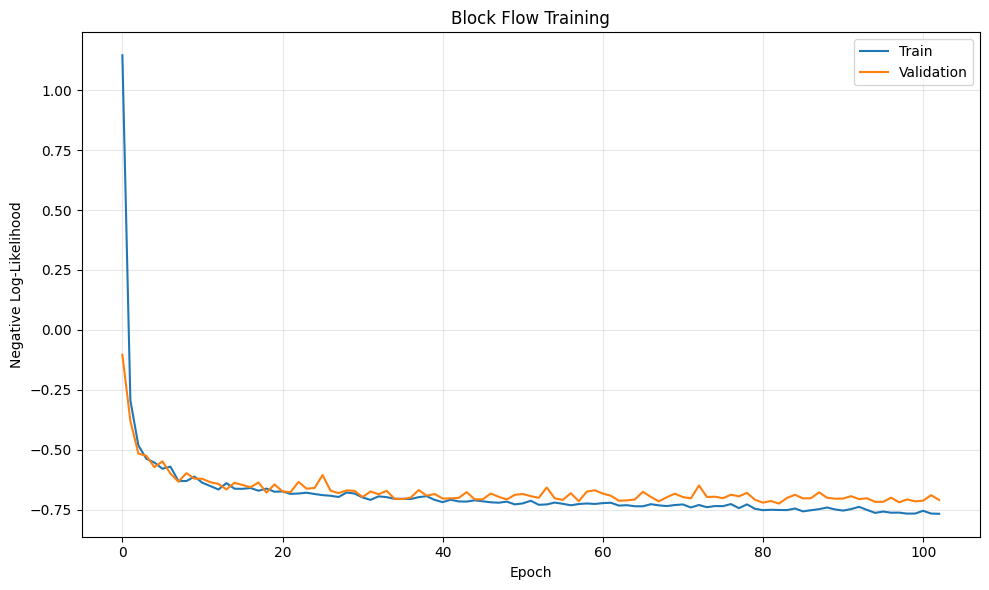

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('Block Flow Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('block_flow_training_curve.png', dpi=150)
plt.show()

## 5. Quick Visualization

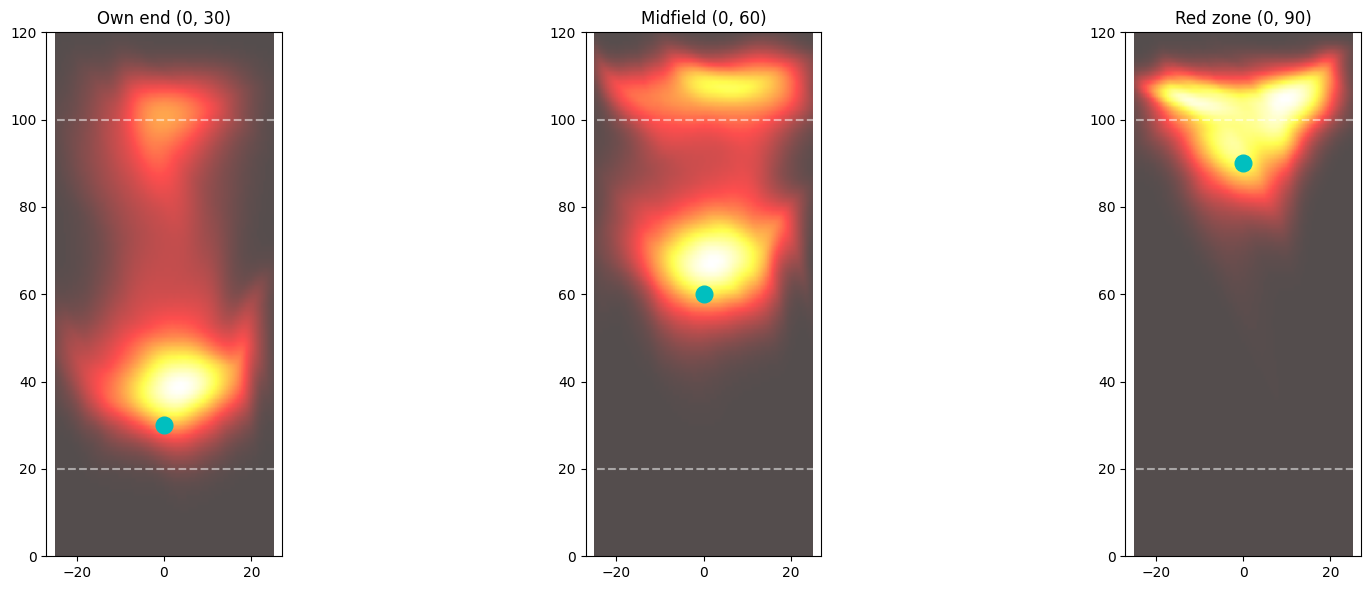

In [11]:
def predict_block_distribution(flow, context_net, thrower_x, thrower_y, grid_size=100):
    flow.eval()
    context_net.eval()
    x_norm = (thrower_x + 25) / 50
    y_norm = thrower_y / 120
    ctx = torch.FloatTensor([[x_norm, y_norm]])

    with torch.no_grad():
        ctx_features = context_net(ctx)
        x_bins = np.linspace(0, 1, grid_size)
        y_bins = np.linspace(0, 1, int(grid_size * 1.2))
        xx, yy = np.meshgrid(x_bins, y_bins)
        grid_points = torch.FloatTensor(np.stack([xx.ravel(), yy.ravel()], axis=1))
        ctx_expanded = ctx_features.expand(grid_points.shape[0], -1)
        log_probs = flow.log_prob(grid_points, context=ctx_expanded)
        probs = torch.exp(log_probs).numpy()
        grid = probs.reshape(len(y_bins), len(x_bins))
    return grid


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
positions = [(0, 30, 'Own end'), (0, 60, 'Midfield'), (0, 90, 'Red zone')]

for ax, (tx, ty, label) in zip(axes, positions):
    grid = predict_block_distribution(flow, context_net, tx, ty)
    ax.imshow(grid, extent=[-25, 25, 0, 120], origin='lower', cmap='hot', alpha=0.7)
    ax.plot(tx, ty, 'co', markersize=12)
    ax.axhline(y=20, color='white', linestyle='--', alpha=0.5)
    ax.axhline(y=100, color='white', linestyle='--', alpha=0.5)
    ax.set_title(f'{label} ({tx}, {ty})')
    ax.set_xlim(-27, 27)
    ax.set_ylim(0, 120)

plt.tight_layout()
plt.show()

## 6. Save Model

In [12]:
os.makedirs('models', exist_ok=True)

save_dict = {
    'flow_state_dict': flow.state_dict(),
    'context_net_state_dict': context_net.state_dict(),
    'hyperparameters': {
        'num_layers': NUM_LAYERS,
        'hidden_features': HIDDEN_FEATURES,
        'context_features': CONTEXT_FEATURES,
    },
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
}

joblib.dump(save_dict, 'models/block_flow_model.pkl')
print('Saved to models/block_flow_model.pkl')

Saved to models/block_flow_model.pkl
